In [1]:
###### H=∑1/2 . π_i^2​+1/2​m^22ϕ_i^2​+1/2​∑​(ϕ_i−ϕ_j)^2 #####

####p(ϕ)∝exp(−ϕ^TKϕ)####
#### K=−∇^2+m^2 ###
#### (Kϕ)_i=(2+m^2)ϕ_i−ϕ_{i+1}−ϕ_{i−1}





import numpy as np
### Build K ###

def build_K(L, m):
    K = np.zeros((L, L))
    
    for i in range(L):
        K[i, i] = 2 + m**2
        K[i, (i+1) % L] = -1
        K[i, (i-1) % L] = -1
    
    return K

### ϕ∼N(0,K−1) ###
### K=UΛU^T ###
### ϕ= UΛ^{-1/2}η
### η∼N(0,I) ###
def sample_phi(L=16, m=1.0, n_samples=1000):
    K = build_K(L, m)
    
    # Diagonalize K
    eigvals, eigvecs = np.linalg.eigh(K)
    
    # Avoid numerical issues
    eigvals = np.maximum(eigvals, 1e-12)
    
    # Construct K^{-1/2}
    Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eigvals))
    
    samples = []
    
    for _ in range(n_samples):
        eta = np.random.randn(L)
        phi = eigvecs @ Lambda_inv_sqrt @ eta
        samples.append(phi)
    
    return np.array(samples), K

In [2]:
##### Check mean
samples, K = sample_phi()

print(np.mean(samples))   # should be ~0

-0.0035748615007781355


True


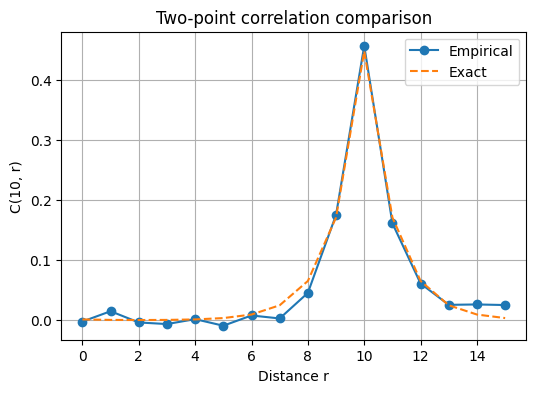

In [3]:
### Two point function C_{ij}=⟨ϕ_i.ϕ_j⟩
import matplotlib.pyplot as plt

C_empirical = np.cov(samples.T)
C_exact = np.linalg.inv(K)

print(np.allclose(C_empirical, C_exact, atol=1e-1))
# Take correlation from site 0
emp = C_empirical[10]
exact = C_exact[10]

plt.figure(figsize=(6,4))
plt.plot(emp, 'o-', label='Empirical')
plt.plot(exact, '--', label='Exact')
plt.xlabel("Distance r")
plt.ylabel("C(10, r)")
plt.title("Two-point correlation comparison")
plt.legend()
plt.grid(True)
plt.show()

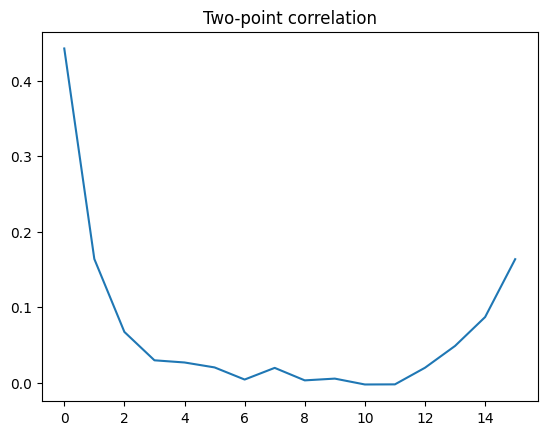

In [4]:
## Translational invariance

import matplotlib.pyplot as plt

corr = C_empirical[0]  # correlation from site 0
plt.plot(corr)
plt.title("Two-point correlation")
plt.show()

In [5]:
import pandas as pd

# samples from your function
samples, K = sample_phi(L=16, m=1.0, n_samples=10000)

df = pd.DataFrame({
    "state": list(samples)   # each row is a vector
})

df.to_hdf("fsft_dataset.h5", key="data", mode="w")

/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_8110/698250629.py:10: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['state'], dtype='str')]

  df.to_hdf("fsft_dataset.h5", key="data", mode="w")
